SETUP & DATA PREPARATION

In [1]:
!pip install -q kagglehub
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Add, Activation, BatchNormalization, concatenate, GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
NUM_CLASSES = 4 # 4 Expressions only
# Download Dataset
print("Downloading dataset directly from Kaggle...")
base_path = kagglehub.dataset_download("anshtanwar/pets-facial-expression-dataset")
subdirs = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
dataset_path = subdirs[0] if len(subdirs) == 1 else base_path
print(f"Dataset is ready at: {dataset_path}")
# Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
    horizontal_flip=True, validation_split=0.2
)
# FILTERING CLASSES (Skipping "Master Folder")
valid_classes = ['Angry', 'happy', 'Sad', 'Other']
print("\nLoading Training Data:")
train_generator = train_datagen.flow_from_directory(
    dataset_path, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, classes=valid_classes,
    class_mode='categorical', subset='training'
)
print("\nLoading Validation Data:")
validation_generator = train_datagen.flow_from_directory(
    dataset_path, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, classes=valid_classes,
    class_mode='categorical', subset='validation', shuffle=False
)

Using Colab cache for faster access to the 'pets-facial-expression-dataset' dataset.
Dataset is ready at: /kaggle/input/pets-facial-expression-dataset

Loading Training Data:
Found 800 images belonging to 4 classes.

Loading Validation Data:
Found 200 images belonging to 4 classes.


DENSENET121 ARCHITECTURE (SCRATCH)

In [2]:
def dense_block(x, num_layers, growth_rate):
    for _ in range(num_layers):
        cb = BatchNormalization()(x)
        cb = Activation('relu')(cb)
        cb = Conv2D(4 * growth_rate, (1, 1), padding='same')(cb)
        cb = BatchNormalization()(cb)
        cb = Activation('relu')(cb)
        cb = Conv2D(growth_rate, (3, 3), padding='same')(cb)
        x = concatenate([x, cb])
    return x
def transition_block(x, compression=0.5):
    num_filters = int(x.shape[-1] * compression)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(num_filters, (1, 1), padding='same')(x)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)
    return x
def build_densenet(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    growth_rate = 32
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (7, 7), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    # Note: If Colab crashes due to RAM, change num_layers=24 to 16 in Block 3.
    x = dense_block(x, num_layers=6, growth_rate=growth_rate)
    x = transition_block(x)
    x = dense_block(x, num_layers=12, growth_rate=growth_rate)
    x = transition_block(x)
    x = dense_block(x, num_layers=24, growth_rate=growth_rate)
    x = transition_block(x)
    x = dense_block(x, num_layers=16, growth_rate=growth_rate)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs, name="DenseNet_Scratch")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

TRAINING & EVALUATION (SCRATCH)


Training DenseNet from Scratch
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.2912 - loss: 1.6206 - val_accuracy: 0.2550 - val_loss: 3.5532
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 656ms/step - accuracy: 0.3462 - loss: 1.3793 - val_accuracy: 0.2750 - val_loss: 1.4334
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 646ms/step - accuracy: 0.3487 - loss: 1.3558 - val_accuracy: 0.2500 - val_loss: 1.5627
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 649ms/step - accuracy: 0.3550 - loss: 1.3553 - val_accuracy: 0.2650 - val_loss: 1.4203
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 762ms/step - accuracy: 0.3762 - loss: 1.3402 - val_accuracy: 0.2700 - val_loss: 1.4143
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 641ms/step - accuracy: 0.3525 - loss: 1.3310 - val_accuracy: 0.3000 - val_loss: 1.5597
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 646ms/step - accuracy: 0.3650 - loss: 1.3626 - val_accuracy: 0.2500 - val_loss: 1.4333
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 697ms/step - accuracy: 0.

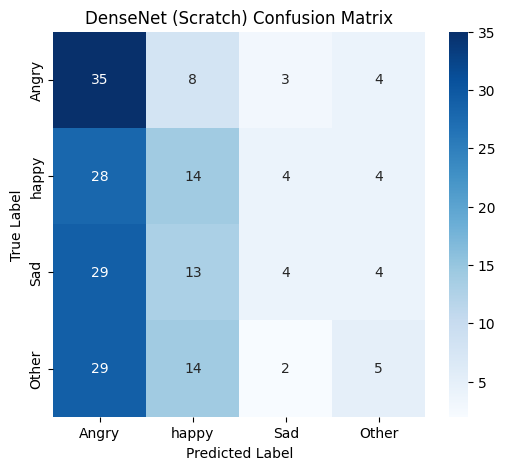

In [3]:
print("\n" + "="*40 + "\nTraining DenseNet from Scratch\n" + "="*40)
densenet_scratch = build_densenet()
# Train the model
EPOCHS_SCRATCH = 15
history_scratch = densenet_scratch.fit(
    train_generator,
    epochs=EPOCHS_SCRATCH,
    validation_data=validation_generator,
    verbose=1
)
# Evaluate
validation_generator.reset()
y_pred = np.argmax(densenet_scratch.predict(validation_generator), axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())
print(f"\n--- Classification Report (DenseNet Scratch) ---")
print(classification_report(y_true, y_pred, target_names=class_labels))
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('DenseNet (Scratch) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

TRANSFER LEARNING (DENSENET121)


Applying ImageNet Transfer Learning to DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.3562 - loss: 1.5729 - val_accuracy: 0.4650 - val_loss: 1.1690
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 571ms/step - accuracy: 0.4450 - loss: 1.1631 - val_accuracy: 0.5250 - val_loss: 1.0318
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 562ms/step - accuracy: 0.4863 - loss: 1.1083 - val_accuracy: 0.6250 - val_loss: 0.9907
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 575ms/step - accuracy: 0.4850 - loss: 1.1050 - val_accuracy: 0.6100 - val_loss: 0.9416
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 584ms/step - accuracy: 0.5250 - loss: 1.0720 - val_accuracy: 0.6750 - val_loss: 0.8960
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step - accuracy: 0.6050 - loss: 0.9585 - val_accuracy: 0.6650 - val_loss: 0.8641
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 570ms/step - accuracy: 0.6388 - loss: 0.8969 - val_accuracy: 0.6950 - val_loss: 0.80

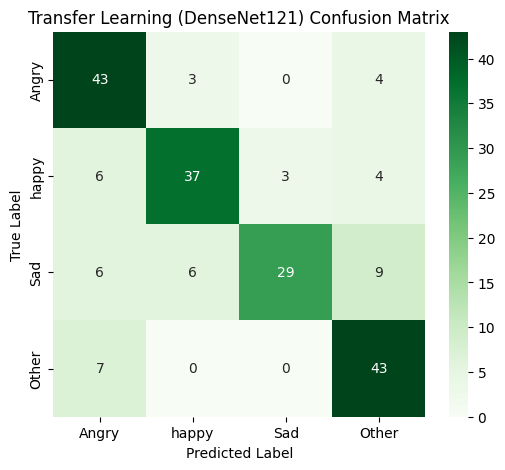

In [4]:
print("\n" + "="*40 + "\nApplying ImageNet Transfer Learning to DenseNet121\n" + "="*40)
# Load the built-in DenseNet121 with ImageNet weights
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Freeze the convolutional base
for layer in base_model.layers:
    layer.trainable = False
# Add custom classification head for our 4 classes
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
densenet_tl = Model(inputs=base_model.input, outputs=outputs, name="DenseNet_TL")
densenet_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the Transfer Learning model
EPOCHS_TL = 10
history_tl = densenet_tl.fit(
    train_generator,
    epochs=EPOCHS_TL,
    validation_data=validation_generator,
    verbose=1
)
# Final Evaluation
validation_generator.reset()
y_pred_tl = np.argmax(densenet_tl.predict(validation_generator), axis=1)
y_true_tl = validation_generator.classes
print(f"\n--- FINAL TRANSFER LEARNING REPORT (DenseNet121) ---")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_labels))
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true_tl, y_pred_tl), annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Transfer Learning (DenseNet121) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()